In [1]:
import numpy as np
import subprocess

current_numpy = np.__version__
print(f"Locking version to pre-loaded Numpy: {current_numpy}")

command = f"pip install caustics astropy numpy=={current_numpy}"

subprocess.run(command, shell=True)

Locking version to pre-loaded Numpy: 2.0.2
INFO: pip is looking at multiple versions of caskade to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of caskade to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of astropy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 79.0 MB/s eta 0:00:00
  Attempting uninstall: graphviz
    Fou

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-adk 1.25.1 requires graphviz<1.0.0,>=0.20.2, but you have graphviz 0.20.1 which is incompatible.


CompletedProcess(args='pip install caustics astropy numpy==2.0.2', returncode=0)

In [2]:
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

import torch
import torch.nn as nn

import torchvision
from torchvision import transforms

In [3]:
!pip install caustics

In [4]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
SEED = 42
LAMBDA = 0.5

In [5]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

In [6]:
device = "cpu"
if torch.cuda.is_available():
    print(f"Cuda Version:{torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    device = "cuda"
print(f"Using device: {device}")

Cuda Version:12.8
GPU Memory: 15.6 GB
Using device: cuda


## Dataset Exploration

In [7]:
root_data_dir = Path('/kaggle/input/datasets/aditibindal/deeplense-dataset-for-ml4sci/dataset')
no_1 = np.load(root_data_dir/'train/no/1.npy')
no_1.shape

(1, 150, 150)

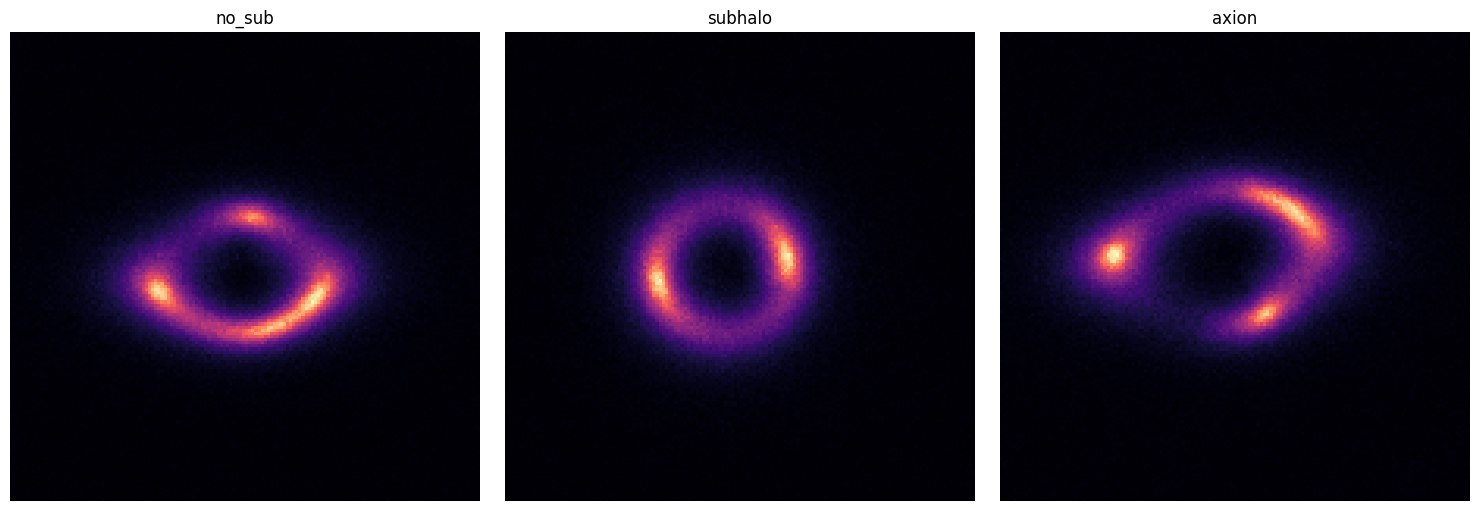

In [8]:
no = np.load(root_data_dir/'train/no/1000.npy')
subhalo = np.load(root_data_dir/'train/sphere/1000.npy')
axion = np.load(root_data_dir/'train/vort/1000.npy')

def plot_train_samples(samples_dict):
    plt.figure(figsize=(15, 5))
    
    for i, (label, img) in enumerate(samples_dict.items()):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img[0], cmap="magma")
        plt.title(label)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

samples = {
    "no_sub": no,
    "subhalo": subhalo,
    "axion": axion,
}

plot_train_samples(samples)

In [9]:
def check_data_split(base_path: Path):
    stats = {}
    for split in ['train', 'val']:
        split_path = base_path / split
        stats[split] = {}
        for class_name in os.listdir(split_path):
            class_path = split_path / class_name
            if class_path.is_dir():
                stats[split][class_name] = len(os.listdir(class_path))
                
    print(f"{'Split':<10} | {'Class':<10} | {'Count':<10}")
    print("-" * 35)
    total_train = 0
    total_val = 0
    
    for split, classes in stats.items():
        for class_name, count in classes.items():
            print(f"{split:<10} | {class_name:<10} | {count:<10}")
            if split == 'train': total_train += count
            else: total_val += count
            
    if total_train + total_val > 0:
        val_ratio = total_val / (total_train + total_val)
        print("-" * 35)
        print(f"Total Images: {total_train + total_val}")
        print(f"Validation Ratio: {val_ratio:.2%} (Target: 10.00%)")
        
check_data_split(root_data_dir)

Split      | Class      | Count     
-----------------------------------
train      | no         | 10000     
train      | vort       | 10000     
train      | sphere     | 10000     
val        | no         | 2500      
val        | vort       | 2500      
val        | sphere     | 2500      
-----------------------------------
Total Images: 37500
Validation Ratio: 20.00% (Target: 10.00%)


## Dataset Preparation

In [10]:
from torch.utils.data import Dataset, DataLoader, random_split

class DeepLenseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort'] 
        self.filepaths = []
        self.labels = []
        
        for label_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(self.root_dir, class_name)
            if os.path.exists(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith('.npy'):
                        self.filepaths.append(os.path.join(class_dir, file))
                        self.labels.append(label_idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, i):
        img_path = self.filepaths[i]
        image = np.load(img_path) 
        
        if image.ndim == 2:
            image = np.expand_dims(image, axis=0)
            
        image = torch.tensor(image, dtype=torch.float32)
        
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        label = self.labels[i]

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
def create_transform_pipelines():
    IMAGENET_MEAN = [0.485, 0.456, 0.406] 
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # standard transformations (resize, center, rotate, normalize)
    train_transforms = transforms.Compose([
        transforms.Resize(256, antialias=True), 
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    val_transforms = transforms.Compose([
        transforms.Resize(256, antialias=True),
        transforms.CenterCrop(224),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    return train_transforms, val_transforms
    
train_transform, val_transform = create_transform_pipelines()

In [12]:
def create_datasets_and_dataloaders(data_dir: Path,
                                  train_transform: transforms.Compose,
                                  val_transform: transforms.Compose,
                                  batch_size: int = BATCH_SIZE,
                                  num_workers: int = 2) -> tuple:

    train_dataset = DeepLenseDataset(root_dir=data_dir/"train", transform=train_transform)
    val_dataset = DeepLenseDataset(root_dir=data_dir/"train", transform=val_transform)
    test_dataset = DeepLenseDataset(root_dir=data_dir/"val", transform=val_transform)

    class_names = train_dataset.classes
    
    num_images = len(train_dataset)
    train_size = int(0.9 * num_images)
    val_size = num_images - train_size
    train_idx, val_idx = random_split(
        range(num_images), 
        [train_size, val_size], 
        generator=torch.Generator().manual_seed(42)
    )
    
    train_subset = torch.utils.data.Subset(train_dataset, train_idx)
    val_subset = torch.utils.data.Subset(val_dataset, val_idx)
    
    
    train_dataloader = DataLoader(dataset=train_subset,
                                 batch_size=batch_size,
                                 shuffle=True,
                                 num_workers=num_workers,
                                 persistent_workers=True,
                                 pin_memory=True if device == "cuda" else False)

    val_dataloader = DataLoader(dataset=val_subset,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                persistent_workers=True,
                                pin_memory=True if device == "cuda" else False)
    
    test_dataloader = DataLoader(dataset=test_dataset,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                 persistent_workers=True,
                                pin_memory=True if device == "cuda" else False)

    return train_subset, val_subset, test_dataset, train_dataloader, val_dataloader, test_dataloader, class_names

train_subset, val_subset, test_dataset, train_dataloader, val_dataloader, test_dataloader, class_names = create_datasets_and_dataloaders(
    data_dir=root_data_dir,
    train_transform=train_transform,
    val_transform=val_transform,
    batch_size=BATCH_SIZE,
    num_workers=2
)

print("=== DATASET AND DATALOADER SUMMARY ===")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")
print(f"Batch size: {train_dataloader.batch_size}")
print(f"Training batches per epoch: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

=== DATASET AND DATALOADER SUMMARY ===
Training samples: 27000
Validation samples: 3000
Test samples: 7500
Number of classes: 3
Class names: ['no', 'sphere', 'vort']
Batch size: 64
Training batches per epoch: 422
Validation batches: 47
Test batches: 118


In [13]:
images, labels = next(iter(train_dataloader))
print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 224, 224])
Labels batch shape: torch.Size([64])


## Building Auxiliary PINN

In [14]:
output_shape = len(class_names)

In [15]:
import torchvision.models as models
import caustics

class AuxPINN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head1 = nn.Linear(512, 1)
        torch.nn.init.zeros_(self.head1.weight)
        torch.nn.init.zeros_(self.head1.bias)
        self.head2 = nn.Linear(512 + 1, output_shape)
        
    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)
        predicted_radius = torch.sigmoid(self.head1(features)) * 3.0
        combined_features = torch.cat((features, predicted_radius), dim=1)
        
        class_logits = self.head2(combined_features)
        
        return class_logits, predicted_radius

model = AuxPINN().to(device)
from torchsummary import summary
summary(model=model, input_size=(3, 224, 224))
model = torch.compile(model, mode="reduce-overhead")
print(f"Auxiliary neural net built and moved to {device}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 171MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [16]:
cosmology = caustics.FlatLambdaCDM(name="cosmo")

lens = caustics.SIS(cosmology=cosmology, name="lens", z_l=0.5, z_s=1.0, x0=0.0, y0=0.0, Rein=None)
source = caustics.Sersic(name="source", x0=0.0, y0=0.0, q=0.5, phi=0.0, n=1.0, Re=1.0, Ie=10.0)

sim = caustics.LensSource(lens=lens, source=source, pixelscale=0.05, pixels_x=224, name="sim")
sim = sim.to(device)

print(f"Built 224x224 Differentiable physics simulator and moved to {device}")

Built 224x224 Differentiable physics simulator and moved to cuda


## Train Model

In [17]:
criterion_head1 = nn.MSELoss()
criterion_head2 = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [18]:
import copy
import time

def train_pinn(model, train_dataloader, val_dataloader, optimizer, criterion_head1, criterion_head2, sim, device, epochs=10, lambda_weight=0.5):
    print("Starting AuxPINN Training...")
    print("-" * 70)
    
    start_time = time.time()
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    results = {
        'train_loss': [], 'train_class_loss': [], 'train_phys_loss': [], 'train_acc': [],
        'val_loss': [], 'val_class_loss': [], 'val_phys_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss, train_class_loss, train_phys_loss = 0.0, 0.0, 0.0
        train_acc, train_total = 0, 0
        
        train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            class_logits, predicted_radius = model(images)
            loss_class = criterion_head2(class_logits, labels)
            
            sim_fn = lambda r: sim({"lens": {"Rein": r}})
            simulated_images = torch.vmap(sim_fn)(predicted_radius.view(-1))
            real_images_1ch = images[:, 0, :, :] 
            loss_physics = criterion_head1(simulated_images.squeeze(), real_images_1ch)
            
            total_loss = loss_class + (lambda_weight * loss_physics)
            
            total_loss.backward()
            optimizer.step()
            
            train_loss += total_loss.item()
            train_class_loss += loss_class.item()
            train_phys_loss += loss_physics.item()
            _, preds = torch.max(class_logits, 1)
            train_acc += torch.sum(preds == labels.data).item()
            train_total += labels.size(0)

            train_bar.set_postfix({'loss': f"{total_loss.item():.4f}"})
    
        model.eval()
        val_loss, val_class_loss, val_phys_loss = 0.0, 0.0, 0.0
        val_acc, val_total = 0, 0
        val_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        
        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                
                class_logits, predicted_radius = model(images)
                loss_class = criterion_head2(class_logits, labels)
                
                sim_fn = lambda r: sim({"lens": {"Rein": r}})
                simulated_images = torch.vmap(sim_fn)(predicted_radius.view(-1))
                real_images_1ch = images[:, 0, :, :] 
                loss_physics = criterion_head1(simulated_images.squeeze(), real_images_1ch)
                
                total_loss = loss_class + (lambda_weight * loss_physics)
                
                val_loss += total_loss.item()
                val_class_loss += loss_class.item()
                val_phys_loss += loss_physics.item()
                _, preds = torch.max(class_logits, 1)
                val_acc += torch.sum(preds == labels.data).item()
                val_total += labels.size(0)

        train_acc /= train_total
        val_acc /= val_total

        results['train_loss'].append(train_loss / len(train_dataloader))
        results['train_class_loss'].append(train_class_loss / len(train_dataloader))
        results['train_phys_loss'].append(train_phys_loss / len(train_dataloader))
        results['train_acc'].append(train_acc)

        results['val_loss'].append(val_loss / len(val_dataloader))
        results['val_class_loss'].append(val_class_loss / len(val_dataloader))
        results['val_phys_loss'].append(val_phys_loss / len(val_dataloader))
        results['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d}/{epochs}")
        print(f"  TRAIN | Loss: {results['train_loss'][-1]:.4f} (Class: {results['train_class_loss'][-1]:.4f}, Phys: {results['train_phys_loss'][-1]:.4f}) | Acc: {results['train_acc'][-1]:.4f}")
        print(f"  VAL   | Loss: {results['val_loss'][-1]:.4f} (Class: {results['val_class_loss'][-1]:.4f}, Phys: {results['val_phys_loss'][-1]:.4f}) | Acc: {results['val_acc'][-1]:.4f}")
        print("-" * 70)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_aux_pinn_model.pth')
            print(f"New best model. Weights saved.")
        print("-" * 75)

    model.load_state_dict(best_model_wts)

    mins, secs = divmod(time.time() - start_time, 60)
    print(f"Training Complete in {int(mins)}m {int(secs)}s")
    return model, results

In [19]:
model, results = train_pinn(
    model=model, 
    train_dataloader=train_dataloader,  
    val_dataloader=val_dataloader,      
    optimizer=optimizer, 
    criterion_head1=criterion_head1, 
    criterion_head2=criterion_head2, 
    sim=sim, 
    device=device, 
    epochs=NUM_EPOCHS,
    lambda_weight=LAMBDA
)

Starting AuxPINN Training...
----------------------------------------------------------------------


Epoch 1/20 [Train]:   0%|          | 0/422 [00:00<?, ?it/s]

W0328 08:44:36.650000 24 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/20 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch  1/20
  TRAIN | Loss: 9.0049 (Class: 0.7803, Phys: 16.4492) | Acc: 0.6155
  VAL   | Loss: 6.4035 (Class: 0.5154, Phys: 11.7762) | Acc: 0.8257
----------------------------------------------------------------------
New best model. Weights saved.
---------------------------------------------------------------------------


...

Epoch 19/20 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 19/20
  TRAIN | Loss: 5.8368 (Class: 0.1043, Phys: 11.4650) | Acc: 0.9637
  VAL   | Loss: 5.9164 (Class: 0.1895, Phys: 11.4539) | Acc: 0.9433
----------------------------------------------------------------------
---------------------------------------------------------------------------


Epoch 20/20 [Train]:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 20/20
  TRAIN | Loss: 5.8356 (Class: 0.1032, Phys: 11.4648) | Acc: 0.9641
  VAL   | Loss: 5.8865 (Class: 0.1596, Phys: 11.4538) | Acc: 0.9480
----------------------------------------------------------------------
---------------------------------------------------------------------------
Training Complete in 51m 28s


## Evaluation

In [20]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

def evaluate_pinn_model(model, test_dataloader, criterion, device):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    all_probs = [] 
    
    test_pbar = tqdm(test_dataloader, desc='Evaluating on test set')
    with torch.no_grad():
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs, predicted_radius = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            probs = torch.nn.functional.softmax(outputs, dim=1)  
            _, predicted = torch.max(outputs, 1)
            
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  
            
            test_pbar.set_postfix({'loss': loss.item(), 'acc': test_correct/test_total})
    
    test_loss = test_loss / len(test_dataloader.dataset)
    test_acc = test_correct / test_total
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    
    cm = confusion_matrix(all_labels, all_preds)
    
    all_labels_np = np.array(all_labels)
    all_probs_np = np.array(all_probs)
    
    n_classes = all_probs_np.shape[1]
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        binary_labels = (all_labels_np == i).astype(int)
        class_probs = all_probs_np[:, i]
        
        fpr[i], tpr[i], _ = roc_curve(binary_labels, class_probs)
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    macro_roc_auc = sum(roc_auc.values()) / n_classes
    print(f'Macro-averaged ROC AUC: {macro_roc_auc:.4f}')
    
    return test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc

In [21]:
def plot_roc_curves(fpr, tpr, roc_auc, class_names, save_path=None):
    plt.figure(figsize=(10, 8))
    
    for i in fpr.keys():
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'ROC curve for {class_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_results(results, save_path='training_results.png'):
    num_epochs = len(results['train_loss'])
    plt.figure(figsize=(12, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(results['train_loss'], label='Train Loss')
    plt.plot(results['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epoch')
    plt.xlim(0, num_epochs - 1)
    
    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(results['train_acc'], label='Train Accuracy')
    plt.plot(results['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epoch')
    plt.xlim(0, num_epochs - 1) 
    plt.ylim(0, 1.05) 
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def plot_confusion_matrix(cm, class_names, save_path='confusion_matrix.png'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(save_path)
    plt.show()

Evaluating AuxPINN Model


Evaluating on test set:   0%|          | 0/118 [00:00<?, ?it/s]

Test Loss: 0.1514, Test Accuracy: 0.9528
Macro-averaged ROC AUC: 0.9925

Plotting Training results


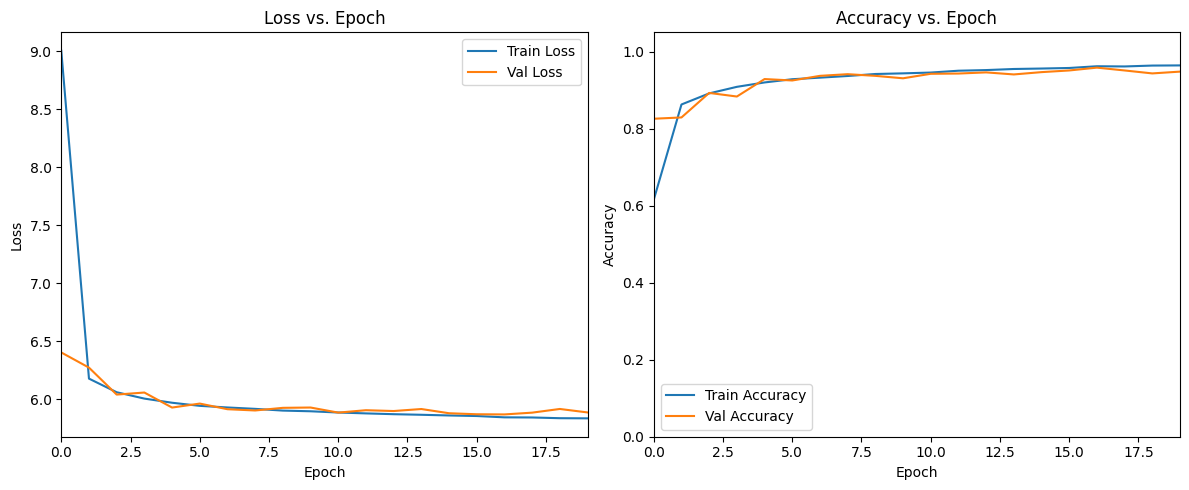


Plotting ROC Curves


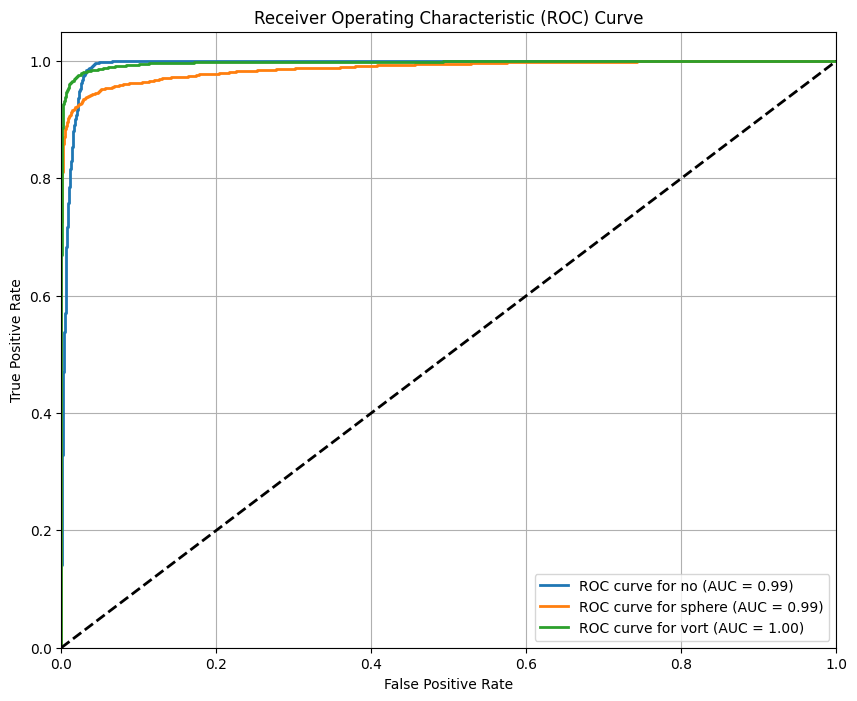


Plotting Confusion Matrix


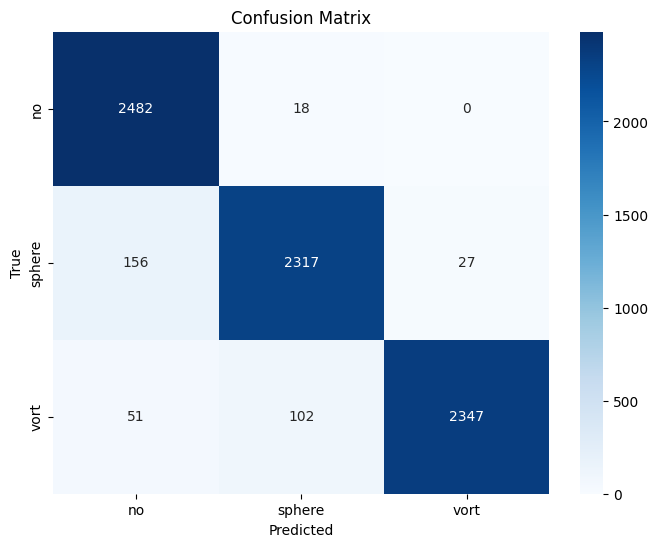

In [22]:
print("Evaluating AuxPINN Model")
test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc = evaluate_pinn_model(
    model=model,
    test_dataloader=test_dataloader,
    criterion=criterion_head2,
    device=device
)

print("\nPlotting Training results")
plot_results(results, save_path='pinn_results.png')

print("\nPlotting ROC Curves")
plot_roc_curves(fpr, tpr, roc_auc, class_names, save_path='pinn_roc.png')

print("\nPlotting Confusion Matrix")
plot_confusion_matrix(cm, class_names, save_path='pinn_cm.png')